<a href="https://colab.research.google.com/github/rapsandhani/DataScience_240401010174_AbdullahRapsandani/blob/main/Pertemuan7_AbdullahRapsandani_240401010174.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#### Nama Lengkap  : Abdullah Rapsandani
#### NIM           : 240401010174
#### Kelas         : IF403


# **Sesi 7 – Pengantar Machine Learning: Regresi Linear**

# STEP 1 — Generate & Eksplorasi Dataset

=== Shape Dataset ===
(300, 4)

=== Deskripsi Statistik ===
       pengalaman     edu    gaji
count      300.00  300.00  300.00
mean         9.90    0.89   27.40
std          5.89    0.83   13.41
min          0.10    0.00    1.67
25%          4.78    0.00   16.24
50%         10.23    1.00   27.97
75%         15.14    2.00   38.89
max         19.80    2.00   54.22


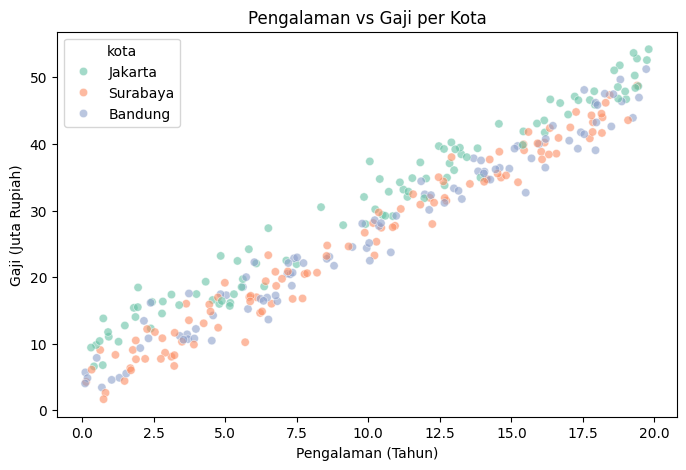

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Generate dataset sintetis
np.random.seed(42)
n = 300
pengalaman = np.random.uniform(0, 20, n)
edu = np.random.choice([0, 1, 2], n) # SMA=0, D3=1, S1=2
kota = np.random.choice(['Jakarta', 'Surabaya', 'Bandung'], n)

# Rumus dasar pembuatan target gaji + noise
gaji = (3.0 + 2.2 * pengalaman + 1.5 * edu
        + np.where(kota == 'Jakarta', 4.0, 0)
        + np.random.normal(0, 2, n))

df = pd.DataFrame({
    'pengalaman': pengalaman,
    'edu': edu,
    'kota': kota,
    'gaji': gaji
})

# 2. EDA singkat
print('=== Shape Dataset ===')
print(df.shape)
print('\n=== Deskripsi Statistik ===')
print(df.describe().round(2))

# 3. Visualisasi Scatter Plot
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='pengalaman', y='gaji', hue='kota', palette='Set2', alpha=0.6)
plt.title('Pengalaman vs Gaji per Kota')
plt.xlabel('Pengalaman (Tahun)')
plt.ylabel('Gaji (Juta Rupiah)')
plt.show()

# STEP 2 — Preprocessing

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. One-Hot Encoding kolom 'kota'
df = pd.get_dummies(df, columns=['kota'], drop_first=True, dtype=int)
print('Kolom setelah encoding:', df.columns.tolist())

# 2. Pisahkan fitur (X) dan target (y)
X = df.drop('gaji', axis=1)
y = df['gaji']

# 3. Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train: {X_train.shape[0]} baris, Test: {X_test.shape[0]} baris')

# 4. StandardScaler — fit pada training set dan transform pada keduanya
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

Kolom setelah encoding: ['pengalaman', 'edu', 'gaji', 'kota_Jakarta', 'kota_Surabaya']
Train: 240 baris, Test: 60 baris


# STEP 3 — Latih Model & Tampilkan Koefisien

In [ ]:
from sklearn.linear_model import LinearRegression

# 1. Inisialisasi dan Latih Model
model = LinearRegression()
model.fit(X_train_s, y_train)

# 2. Tampilkan Intercept dan Koefisien
print(f'β0 (intercept): {model.intercept_:.3f}\n')

coef_df = pd.DataFrame({
    'Fitur': X.columns,
    'Koefisien': model.coef_.round(3)
}).sort_values('Koefisien', ascending=False)

print('=== Koefisien Fitur ===')
print(coef_df.to_string(index=False))

β0 (intercept): 27.514

=== Koefisien Fitur ===
        Fitur  Koefisien
   pengalaman     13.042
 kota_Jakarta      1.837
          edu      1.188
kota_Surabaya     -0.292


# STEP 4 — Evaluasi Model

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1. Prediksi data test
y_pred = model.predict(X_test_s)

# 2. Hitung Metrik (Menggunakan np.sqrt untuk menghindari error squared=False)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse) # Menggunakan NumPy agar aman di semua versi scikit-learn
r2 = r2_score(y_test, y_pred)

print('=== Metrik Evaluasi ===')
print(f'MAE = {mae:.3f} juta rupiah')
print(f'RMSE = {rmse:.3f} juta rupiah')
print(f'R2 = {r2:.4f} ({r2*100:.1f}% variasi dijelaskan)')
print(f'Selisih RMSE-MAE = {rmse-mae:.3f}\n')

=== Metrik Evaluasi ===
MAE = 1.649 juta rupiah
RMSE = 2.123 juta rupiah
R2 = 0.9740 (97.4% variasi dijelaskan)
Selisih RMSE-MAE = 0.474



# STEP 5 — Visualisasi & Interpretasi

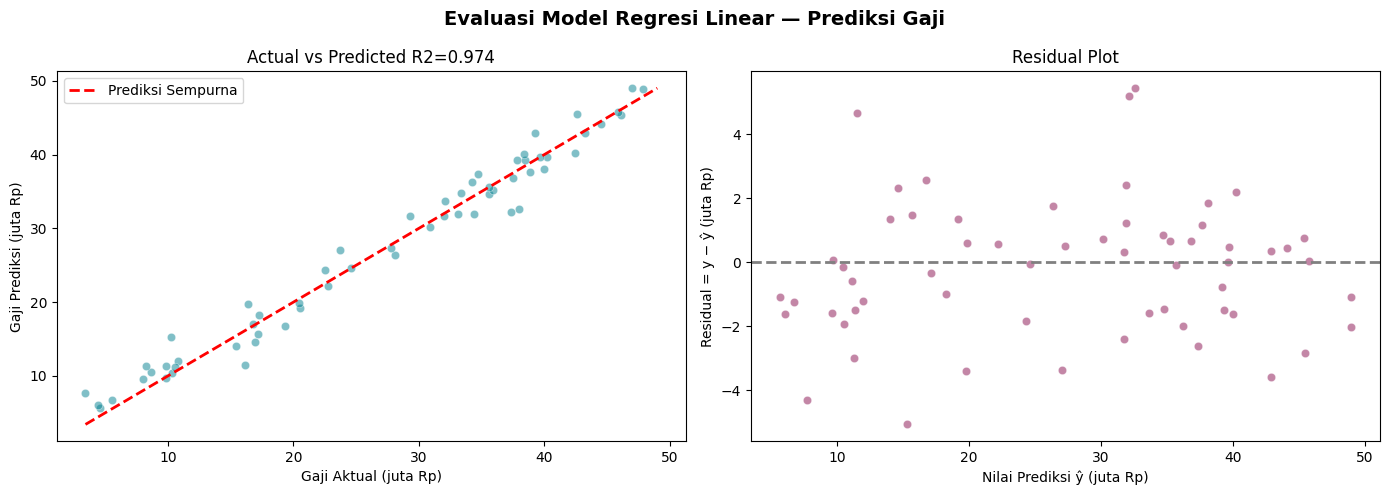

In [ ]:
# 3. Visualisasi Actual vs Predicted & Residual Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.5, color='#028090', edgecolors='white', lw=0.5)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, 'r--', lw=2, label='Prediksi Sempurna')
axes[0].set_xlabel('Gaji Aktual (juta Rp)')
axes[0].set_ylabel('Gaji Prediksi (juta Rp)')
axes[0].set_title(f'Actual vs Predicted R2={r2:.3f}')
axes[0].legend()

# Plot 2: Residual Plot
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.5, color='#880E4F', edgecolors='white', lw=0.5)
axes[1].axhline(0, color='gray', linestyle='--', lw=2)
axes[1].set_xlabel('Nilai Prediksi ŷ (juta Rp)')
axes[1].set_ylabel('Residual = y − ŷ (juta Rp)')
axes[1].set_title('Residual Plot')

plt.suptitle('Evaluasi Model Regresi Linear — Prediksi Gaji', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('evaluasi_regresi.png', dpi=150, bbox_inches='tight')
plt.show()


**Interpretasi Evaluasi Model Regresi Linear — Prediksi Gaji**

---

1. Plot 1: Actual vs Predicted (Aktual vs Prediksi)  
   * **What?**  
     * Titik-titik data berwarna biru kehijauan tampak mengikuti garis diagonal merah, menandakan hasil prediksi mendekati nilai aktual dengan koefisien determinasi tinggi ($R^2$ ≈ 0.97).  
   * **So what?**  
     * Model mampu menangkap hubungan antara variabel seperti pengalaman kerja, pendidikan, dan lokasi dengan sangat baik. Jarak vertikal yang kecil menunjukkan tingkat kesalahan prediksi yang rendah.  
   * **Now what?**  
     * Langkah berikutnya adalah menguji model pada data baru di luar dataset sintetis untuk memastikan performa tetap stabil dan tidak terjadi overfitting.  

2. Plot 2: Residual Plot  
   * **What?**  
     * Titik-titik residual berwarna merah marun tersebar acak di sekitar garis nol, tanpa membentuk pola tertentu di sepanjang sumbu X.  
   * **So what?**  
     * Distribusi residual yang merata menunjukkan bahwa model tidak kehilangan informasi penting dan kesalahan prediksi bersifat acak (white noise).  
   * **Now what?**  
     * Karena pola residual sudah menunjukkan kestabilan, model linear ini masih layak digunakan tanpa perlu beralih ke pendekatan non-linear yang lebih kompleks.  


# Kesimpulan

---

Pada praktikum ini saya mempelajari konsep dasar Machine Learning menggunakan algoritma Regresi Linear untuk memprediksi gaji berdasarkan pengalaman kerja. Model berhasil menunjukkan hubungan positif antara pengalaman kerja dan tingkat gaji.

Temuan utama menunjukkan bahwa semakin besar pengalaman kerja seseorang, maka semakin tinggi prediksi gajinya. Selain itu saya juga belajar melakukan evaluasi model menggunakan MAE, MSE, dan R² Score. Keterbatasan dari praktikum ini adalah dataset yang digunakan masih sederhana sehingga belum sepenuhnya mencerminkan kondisi dunia nyata.